# Participant-level medication effects

The population-level colour x medication coefficient describes the average participant in each
subtype. This notebook extracts each participant's own medication effect on prior use from the same
posterior:

$$\text{effect}_i = \beta_{\text{col:med}} + u_{i,\text{col:med}}$$

computed draw by draw (4 chains x 1,000 draws = 4,000 draws per participant), then summarised by the
posterior mean and the 2.5 / 97.5 percentiles.

**Why a refit.** The MCMC cache in `mcmc_cache.py` stores only the population-level draws (`beta`), not
the by-participant draws (`z_u`, `sd_u`). This notebook resamples with the reported settings and seed
and then checks that the population-level draws are identical to the cached ones, so the
participant-level effects provably come from the posterior reported in Figure 2.

**Outputs** go to the gitignored `outputs/` directory at the repo root. Nothing is written to the data
directory.

| File | Contents |
|---|---|
| `participant_medication_effects.csv` | one row per participant, keyed by `participant_id` |
| `participant_medication_effects_draws.npz` | the 4,000 x N draws per subtype, for downstream comparisons |
| `figure5a_participant_effects.pdf` / `.png` | the forest plot |


In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
from imports import *


In [2]:
from config import dir_config
from src.utils import classification_utils
from src.utils.mcmc_cache import (CACHE_DIR, FIT_SETTINGS, TERMS, build_design, ess_bulk,
                                  prepare_trials, rhat, sample_model)

processed_dir = Path(dir_config.data.processed)
filtered_data = pd.read_csv(Path(processed_dir, "processed_all_data_accu_60_filtered.csv"), index_col=None)
processed_metadata = pd.read_csv(Path(processed_dir, "processed_metadata_all_data_accu_60.csv"), index_col=None)
subjects_map, _ = classification_utils.get_subject_classification_ids(processed_metadata)

OUTPUT_DIR = (Path.cwd().parent / "outputs").resolve()
assert not str(OUTPUT_DIR).startswith(str(Path(dir_config.data.processed).parents[0])), "never write to the data dir"
OUTPUT_DIR.mkdir(exist_ok=True)

# cache names in mcmc_cache use the metadata spelling
SUBTYPES = {"tremor": "tremor_dominant", "bradykinetic": "bradykinesia_dominant"}
TITLES = {"tremor": "Tremor Dominant", "bradykinetic": "Bradykinesia Dominant"}
POSTERIOR_COLOR = "#B5541D"
COL_MED = TERMS.index("col:med")
print("outputs ->", OUTPUT_DIR)
print("sampler settings:", FIT_SETTINGS)


PD subjects with ON+OFF sessions: 41
PD subjects with UPDRS subtype: 22
All PD subjects:           41
  Tremor dominant:         11 	 ['P3' 'P6' 'P7' 'P11' 'P12' 'P17' 'P18' 'P19' 'P29' 'P31' 'P32']
  Brady dominant:          10 	 ['P1' 'P4' 'P9' 'P13' 'P20' 'P22' 'P23' 'P28' 'P33' 'P34']
  Intermediate:            1 	 ['P24']
HC subjects:               18 	 ['HC1' 'HC3' 'HC6' 'HC7' 'HC8' 'HC9' 'HC12' 'HC13' 'AV' 'BC' 'BF' 'EM'
 'ES' 'GF' 'GP' 'JA' 'MRM' 'SY']
outputs -> /src/outputs
sampler settings: {'draws': 1000, 'tune': 1000, 'chains': 4, 'target_accept': 0.9, 'seed': 0}


## Refit with the reported settings

About three minutes for both subtypes.


In [3]:
subsets, subject_ids, idata = {}, {}, {}
for subtype, key in SUBTYPES.items():
    subsets[subtype] = prepare_trials(filtered_data, subjects_map[key])
    _, _, _, subject_ids[subtype] = build_design(subsets[subtype])   # the row order of z_u
    idata[subtype] = sample_model(subsets[subtype], **FIT_SETTINGS)
    print(f"{subtype}: {len(subject_ids[subtype])} participants, {len(subsets[subtype]):,} trials, "
          f"{int(idata[subtype].sample_stats['diverging'].values.sum())} divergences")


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 110 seconds.
Initializing NUTS using jitter+adapt_diag...


tremor: 11 participants, 13,518 trials, 0 divergences


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 70 seconds.


bradykinetic: 10 participants, 12,529 trials, 0 divergences


## Check: same posterior as the reported fit

If the population-level draws match the cached draws used for Figure 2, the by-participant draws
sampled alongside them belong to that same posterior.


In [4]:
for subtype in SUBTYPES:
    with np.load(CACHE_DIR / f"{subtype}.npz") as cached:   # read only
        cached_beta = cached["beta"]
    refit_beta = idata[subtype].posterior["beta"].values
    identical = cached_beta.shape == refit_beta.shape and np.allclose(cached_beta, refit_beta, rtol=0, atol=1e-10)
    print(f"{subtype:13s} population draws identical to cached fit: {identical}")
    assert identical, f"{subtype}: refit does not reproduce the reported posterior"


tremor        population draws identical to cached fit: True
bradykinetic  population draws identical to cached fit: True


## Participant-level effects


In [5]:
effect_draws, summary_rows, diagnostics_rows = {}, [], []
for subtype in SUBTYPES:
    post = idata[subtype].posterior
    beta = post["beta"].values[..., COL_MED]                       # (chain, draw)
    u = post["z_u"].values[..., COL_MED] * post["sd_u"].values[..., None, COL_MED]   # (chain, draw, participant)
    effects = beta[..., None] + u                                    # (chain, draw, participant)
    effect_draws[subtype] = effects.reshape(-1, effects.shape[-1])   # (4000, participant)

    for j, participant in enumerate(subject_ids[subtype]):
        draws = effect_draws[subtype][:, j]
        low, high = np.percentile(draws, [2.5, 97.5])
        summary_rows.append({
            "participant_id": participant, "subtype": subtype,
            "mean": draws.mean(), "sd": draws.std(), "2.5%": low, "97.5%": high,
            "P(> 0)": (draws > 0).mean(),
            "interval": "above 0" if low > 0 else "below 0" if high < 0 else "includes 0",
            "r_hat": rhat(effects[..., j]), "ess_bulk": ess_bulk(effects[..., j]),
        })

    sd_draws = post["sd_u"].values[..., COL_MED]
    diagnostics_rows.append({"subtype": subtype, "participants": len(subject_ids[subtype]),
                             "divergences": int(idata[subtype].sample_stats["diverging"].values.sum()),
                             "sd_u[col:med] r_hat": rhat(sd_draws), "sd_u[col:med] ESS": ess_bulk(sd_draws)})

participant_effects = pd.DataFrame(summary_rows).set_index("participant_id")
participant_effects.round(3)


,subtype,mean,sd,2.5%,97.5%,P(> 0),interval,r_hat,ess_bulk
participant_id,,,,,,,,,
P11,tremor,0.385,0.285,-0.184,0.938,0.907,includes 0,1.001,6251.331
P19,tremor,0.295,0.250,-0.194,0.787,0.880,includes 0,1.000,6203.303
P29,tremor,1.160,0.273,0.628,1.697,1.000,above 0,1.000,5619.461
P6,tremor,1.732,0.322,1.121,2.373,1.000,above 0,1.002,4719.717
P32,tremor,0.388,0.265,-0.116,0.899,0.926,includes 0,1.000,6202.296
P31,tremor,-0.904,0.278,-1.444,-0.360,0.000,below 0,1.000,5056.163
P12,tremor,0.864,0.313,0.242,1.468,0.997,above 0,1.001,6225.002
P18,tremor,0.041,0.266,-0.484,0.572,0.572,includes 0,1.001,6077.889
P3,tremor,0.465,0.248,-0.022,0.941,0.969,includes 0,1.000,5833.717


### Diagnostics for the participant-level quantities

The reported diagnostics cover the population-level effects only. These cover what this figure uses.


In [6]:
diag = pd.DataFrame(diagnostics_rows).set_index("subtype")
per_participant = participant_effects.groupby("subtype").agg(max_r_hat=("r_hat", "max"), min_ess=("ess_bulk", "min"))
diag.join(per_participant).round(4)


,participants,divergences,sd_u[col:med] r_hat,sd_u[col:med] ESS,max_r_hat,min_ess
subtype,,,,,,
tremor,11,0,1.0008,1412.1020,1.0024,4719.7168
bradykinetic,10,0,1.0021,1653.5411,1.0032,4215.9051


## Counts for the text

Alongside the counts: the between-participant SD of the medication effect, `sd_u[col:med]`. That is
the model's direct estimate of heterogeneity, and it does not depend on thresholding individuals.


In [7]:
count_rows = []
for subtype in SUBTYPES:
    block = participant_effects[participant_effects["subtype"] == subtype]
    pop = idata[subtype].posterior["beta"].values[..., COL_MED].ravel()
    het = idata[subtype].posterior["sd_u"].values[..., COL_MED].ravel()
    count_rows.append({
        "subtype": subtype, "participants": len(block),
        "posterior mean > 0": int((block["mean"] > 0).sum()),
        "95% interval above 0": int((block["interval"] == "above 0").sum()),
        "95% interval below 0": int((block["interval"] == "below 0").sum()),
        "population mean": pop.mean(),
        "population 95% CI": f"[{np.percentile(pop, 2.5):+.2f}, {np.percentile(pop, 97.5):+.2f}]",
        "between-participant SD": het.mean(),
        "SD 95% CI": f"[{np.percentile(het, 2.5):.2f}, {np.percentile(het, 97.5):.2f}]",
    })
counts = pd.DataFrame(count_rows).set_index("subtype")
counts.round(3)


,participants,posterior mean > 0,95% interval above 0,95% interval below 0,population mean,population 95% CI,between-participant SD,SD 95% CI
subtype,,,,,,,,
tremor,11,9,4,1,0.531,"[-0.02, +1.09]",0.862,"[0.51, 1.39]"
bradykinetic,10,5,3,3,0.037,"[-0.54, +0.58]",0.818,"[0.48, 1.36]"


## Figure 5a


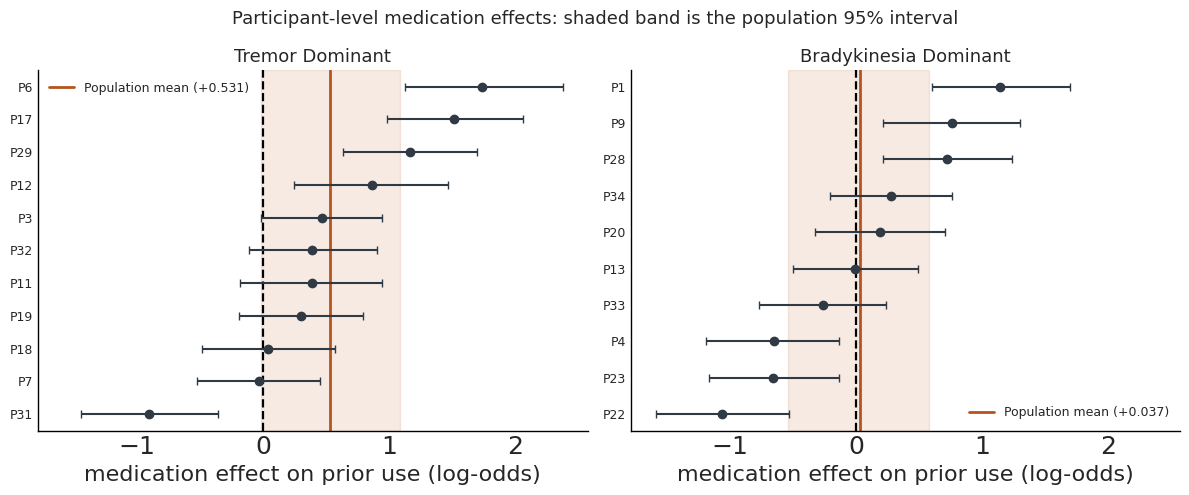

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

for ax, subtype in zip(axes, SUBTYPES):
    block = participant_effects[participant_effects["subtype"] == subtype].sort_values("mean")
    pop = idata[subtype].posterior["beta"].values[..., COL_MED].ravel()
    pop_low, pop_high = np.percentile(pop, [2.5, 97.5])

    ax.axvspan(pop_low, pop_high, color=POSTERIOR_COLOR, alpha=0.12, zorder=0)
    ax.axvline(pop.mean(), color=POSTERIOR_COLOR, lw=2, zorder=1, label=f"Population mean ({pop.mean():+.3f})")
    ax.axvline(0, color="k", ls="--", lw=1.6, zorder=1)

    positions = np.arange(len(block))
    ax.errorbar(
        block["mean"],
        positions,
        xerr=[block["mean"] - block["2.5%"], block["97.5%"] - block["mean"]],
        ls="",
        marker="o",
        ms=6,
        color="#2F3A45",
        capsize=3,
        lw=1.5,
    )
    ax.set_yticks(positions)
    ax.set_yticklabels(block.index, fontsize=9)
    ax.set_xlabel("medication effect on prior use (log-odds)")
    ax.set_title(TITLES[subtype], fontsize=13)
    ax.legend(frameon=False, fontsize=9, loc="best")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

fig.suptitle("Participant-level medication effects: shaded band is the population 95% interval", fontsize=13)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure5a_participant_effects.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "figure5a_participant_effects.png", dpi=200, bbox_inches="tight")
plt.show()


## Results and interpretation

Values are from this run. The refit reproduces the reported posterior draw for draw, so they are
stable across reruns.

| | TD-PD (n = 11) | BD-PD (n = 10) |
|---|---|---|
| Population effect | +0.53 [-0.02, +1.09] | +0.04 [-0.54, +0.58] |
| Posterior mean positive | 9 of 11 | 5 of 10 |
| 95% interval above zero | 4 (P6, P17, P29, P12) | 3 (P1, P9, P28) |
| 95% interval below zero | 1 (P31) | 3 (P22, P23, P4) |
| Interval includes zero | 6 | 4 |
| Range of participant means | -0.90 to +1.73 | -1.06 to +1.15 |
| Between-participant SD | 0.86 [0.51, 1.39] | 0.82 [0.48, 1.36] |

**Heterogeneity is large relative to the average effect.** The between-participant SD of about 0.85
exceeds the TD-PD population effect of 0.53. The population estimate describes the average
participant, not a typical one.

**TD-PD is mostly, but not uniformly, positive.** Nine of eleven participants lean positive and four
have intervals above zero. P31 is clearly negative (-0.90 [-1.44, -0.36]), which is why excluding P31
moves the leave-one-subject-out estimate the most, to +0.70 [+0.25, +1.20].

**The BD-PD population null hides opposite-signed effects.** Three participants have intervals above
zero and three below, and they average to about zero. The data do not show an absence of response in
BD-PD, they show responses in both directions.

**The subtypes differ in centre, not spread.** The two between-participant SDs are almost identical.
Whether the centres differ is tested in `2.27-subtype-comparison`.

### What a participant-level effect contains

Each participant has exactly one OFF and one ON session, so a participant-level "medication effect" is
the difference between that participant's two sessions. It combines medication with everything else
that differed between the sessions: session order, the change in colour-orientation mapping (39 of 41
patients had a different mapping in their second session), and day-to-day variability. Order is
counterbalanced across participants, which protects the population-level estimate, but no individual
estimate is protected.

Consequences:

- The between-participant SD is an **upper bound** on heterogeneity in medication response.
- The BD-PD opposite-direction pattern may be partly session-to-session variation rather than
  opposite responses to medication. These data cannot separate the two.
- Partial pooling shrinks every estimate toward the population mean, so the counts of intervals
  excluding zero are conservative.

### Reporting

Report the between-participant SD as the measure of heterogeneity, and the counts descriptively. Do not
treat individual intervals as tests, and do not describe any individual as a responder or
non-responder to medication, since a single pair of sessions cannot establish that.


## Save


In [9]:
participant_effects.to_csv(OUTPUT_DIR / "participant_medication_effects.csv")
np.savez_compressed(
    OUTPUT_DIR / "participant_medication_effects_draws.npz",
    **{f"{subtype}_draws": effect_draws[subtype] for subtype in SUBTYPES},
    **{f"{subtype}_participant_ids": np.asarray(subject_ids[subtype], dtype=str) for subtype in SUBTYPES},
)
for f in sorted(OUTPUT_DIR.glob("*participant*")):
    print(f"wrote {f.relative_to(OUTPUT_DIR.parent)}")


wrote outputs/figure5a_participant_effects.pdf
wrote outputs/figure5a_participant_effects.png
wrote outputs/participant_medication_effects.csv
wrote outputs/participant_medication_effects_draws.npz
